In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import GEOparse
import os

from sksurv.nonparametric import kaplan_meier_estimator

# for now I will just use the forest model from scikit-survival
from sksurv.ensemble import RandomSurvivalForest
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

from sksurv.datasets import load_gbsg2
from sksurv.ensemble import RandomSurvivalForest
from sksurv.preprocessing import OneHotEncoder
from sksurv.util import Surv


# Load Datasets

In [2]:
#load separate GEO datasets
gse21050 = GEOparse.get_GEO(geo="GSE21050", destdir="./data", silent=True)
gse30929 = GEOparse.get_GEO(geo="GSE30929", destdir="./data", silent=True)
gse71118 = GEOparse.get_GEO(geo="GSE71118", destdir="./data", silent=True)


/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


In [3]:
# get all the metadata
metadata21050 = gse21050.phenotype_data
metadata30929 = gse30929.phenotype_data
metadata71118 = gse71118.phenotype_data


#print the columns of each metadata
#and save as csv for ease of access later
print("Metadata Columns:")
print("GSE21050:")
print(metadata21050.columns)
metadata21050.to_csv("./data/metadata21050.csv")

print("GSE30929:")
print(metadata30929.columns)
metadata30929.to_csv("./data/metadata30929.csv")

print("GSE71118:")
print(metadata71118.columns)
metadata71118.to_csv("./data/metadata71118.csv")

Metadata Columns:
GSE21050:
Index(['title', 'geo_accession', 'status', 'submission_date',
       'last_update_date', 'type', 'channel_count', 'source_name_ch1',
       'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.cohort',
       'characteristics_ch1.1.tissue', 'characteristics_ch1.2.cinsarc group',
       'characteristics_ch1.3.metastasis', 'characteristics_ch1.4.time',
       'characteristics_ch1.5.diagnosis', 'treatment_protocol_ch1',
       'molecule_ch1', 'extract_protocol_ch1', 'label_ch1',
       'label_protocol_ch1', 'hyb_protocol', 'scan_protocol', 'description',
       'data_processing', 'platform_id', 'contact_name', 'contact_email',
       'contact_laboratory', 'contact_department', 'contact_institute',
       'contact_address', 'contact_city', 'contact_zip/postal_code',
       'contact_country', 'supplementary_file', 'relation', 'series_id',
       'data_row_count', 'characteristics_ch1.3.diagnosis'],
      dtype='object')
GSE30929:
Index(['title', 'geo_accession', '

In [4]:
#keep relevant columns for analysis
#this will be geo_accession, metastasis status, time, and cancer type/diagnosis
# in GSE30929, distant recurrence-free survival (DRFS) is used instead of metastasis
cols_keep_21050 = ['geo_accession','characteristics_ch1.5.diagnosis', 'characteristics_ch1.3.metastasis', 'characteristics_ch1.4.time']
cols_keep_30929 = ['geo_accession', 'source_name_ch1', 'characteristics_ch1.4.drfs', 'characteristics_ch1.5.tt.drfs']
cols_keep_71118 = ['geo_accession', 'source_name_ch1', 'characteristics_ch1.0.metastasis', 'characteristics_ch1.1.time' ]

col_names = ['geo_accession','cancer_type','metastasis_status','time']
# combine all metadata into one dataframe
#this looks a little intense, but it's just renaming columns and concatenating dataframes
metadata = pd.concat([metadata21050[cols_keep_21050].rename(columns=dict(zip(cols_keep_21050, col_names))),
                    metadata30929[cols_keep_30929].rename(columns=dict(zip(cols_keep_30929, col_names))),
                    metadata71118[cols_keep_71118].rename(columns=dict(zip(cols_keep_71118, col_names)))], 
                    keys=['GSE21050','GSE30929','GSE71118']).reset_index(level=0).rename(columns={'level_0':'dataset'})
metadata.head()

,dataset,geo_accession,cancer_type,metastasis_status,time
GSM525806,GSE21050,GSM525806,Liposarcoma - dedifferentiated,no,9
GSM525807,GSE21050,GSM525807,Leiomyosarcoma,yes,1.22
GSM525808,GSE21050,GSM525808,Undifferentiated sarcoma,yes,0.92
GSM525809,GSE21050,GSM525809,Other,yes,1.48
GSM525810,GSE21050,GSM525810,Undifferentiated sarcoma,no,0.21


In [5]:
metadata.cancer_type.value_counts()

cancer_type
Undifferentiated sarcoma            225
Leiomyosarcoma                      173
Other                                73
Liposarcoma - dedifferentiated       62
liposarcoma, well-differentiated     52
Dedifferentiated liposarcoma         44
Myxofibrosarcoma                     43
liposarcoma, dedifferentiated        40
liposarcoma, pleomorphic             20
liposarcoma, myxoid                  17
liposarcoma, myxoid/round cell       11
Liposarcoma                           1
Name: count, dtype: int64

In [6]:
#remove missing data
metadata = metadata.dropna()
metadata.cancer_type.value_counts()

cancer_type
Undifferentiated sarcoma            225
Leiomyosarcoma                      173
Other                                73
Liposarcoma - dedifferentiated       62
liposarcoma, well-differentiated     52
Dedifferentiated liposarcoma         44
Myxofibrosarcoma                     43
liposarcoma, dedifferentiated        40
liposarcoma, pleomorphic             20
liposarcoma, myxoid                  17
liposarcoma, myxoid/round cell       11
Liposarcoma                           1
Name: count, dtype: int64

In [7]:
# keep only data with liposarcoma
sarcoma_list = ['Liposarcoma - dedifferentiated',
 'liposarcoma, dedifferentiated',
 'liposarcoma, myxoid/round cell',
 'liposarcoma, myxoid',
 'liposarcoma, pleomorphic',
 'liposarcoma, well-differentiated',
 'Dedifferentiated liposarcoma',
 'Liposarcoma']

metadata = metadata[metadata.cancer_type.isin(sarcoma_list)]

metadata.cancer_type.value_counts()

cancer_type
Liposarcoma - dedifferentiated      62
liposarcoma, well-differentiated    52
Dedifferentiated liposarcoma        44
liposarcoma, dedifferentiated       40
liposarcoma, pleomorphic            20
liposarcoma, myxoid                 17
liposarcoma, myxoid/round cell      11
Liposarcoma                          1
Name: count, dtype: int64

In original study they use 192 samples, where as the full list is 247. Im wondering if during batch correction they removed 55?

In [8]:
#need to standardize metastasis status values
metadata.metastasis_status.value_counts()

metastasis_status
FALSE    91
TRUE     49
no       46
No       33
yes      16
Yes      12
Name: count, dtype: int64

In [9]:
metastasis_map = {
    'FALSE': False,
    'TRUE': True,
    'no': False,
    'yes': True,
    'No': False,
    'yes': True,
    'Yes': True
    }
metadata['metastasis_status'] = metadata['metastasis_status'].map(metastasis_map)

In [10]:
# convert time to a float
metadata['time'] = metadata['time'].astype('float')

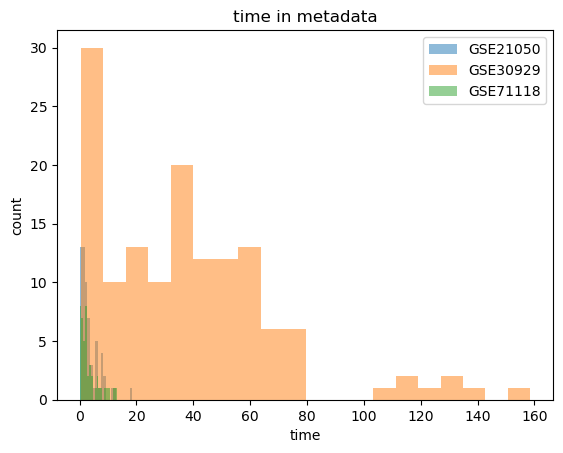

In [11]:
#plot histograms of survival times for each dataset
for dataset in metadata['dataset'].unique():
    data_subset = metadata[metadata['dataset'] == dataset]
    plt.hist(data_subset['time'], bins=20, alpha=0.5, label=dataset)
plt.legend()
plt.title('time in metadata')
plt.xlabel('time')
plt.ylabel('count')
plt.show()

GSE30929 is measured in months, the other two are in years

In [12]:
#convert GSE30950 time to years
metadata.loc[metadata['dataset']=='GSE30929', 'time'] = metadata.loc[metadata['dataset']=='GSE30929', 'time'] / 12

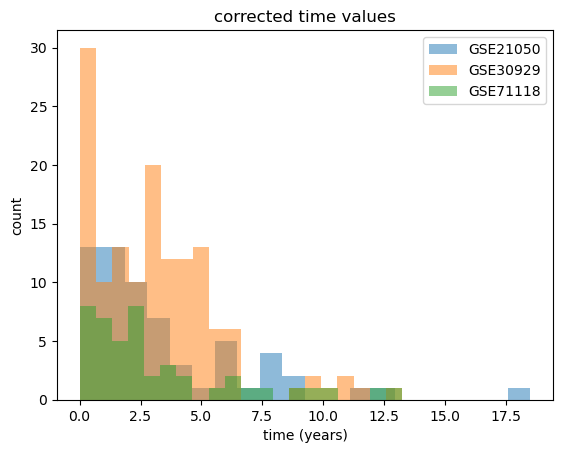

In [13]:
#plot histograms of survival times for each dataset
for dataset in metadata['dataset'].unique():
    data_subset = metadata[metadata['dataset'] == dataset]
    plt.hist(data_subset['time'], bins=20, alpha=0.5, label=dataset)
plt.legend()
plt.title('corrected time values')
plt.xlabel('time (years)')
plt.ylabel('count')
plt.show()

In [14]:
#save combined metadata to csv
metadata.to_csv("./data/combined_metadata.csv", index=False)

# Combining data

In [15]:
table21050 = gse21050.pivot_samples('VALUE')
table30929 = gse30929.pivot_samples('VALUE')
table71118 = gse71118.pivot_samples('VALUE')
#combine expression data
#GSE21050 is not log scaled
expression_data = pd.concat([np.log2(table21050+1), table30929, table71118], axis=1, join='inner')
expression_data.shape

(22215, 762)

In [16]:
# keep only liposarcoma samples in expression data
expression_data = expression_data[metadata['geo_accession']]
expression_data.shape

(22215, 247)

In [17]:
#save combined expression data to csv
expression_data.to_csv("./data/combined_expression_data_unscaled.csv", index=True)


In [18]:
#load expression data
#expression_data = pd.read_csv("./data/combined_expression_data_unscaled.csv", index_col=0)
#metadata = pd.read_csv("./data/combined_metadata.csv")

Text(0.5, 1.0, 'Boxplots of sample probe values')

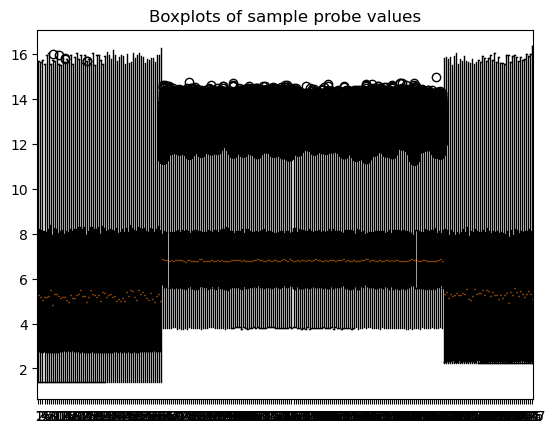

In [19]:
plot = plt.boxplot(expression_data)
plt.title('Boxplots of sample probe values')

It is clear there is some differences in normailization method, this should be removed durring batch correction.

In [20]:
metadata.head()
# Convert the 'color' column to a 'category' dtype
dataset_map = {
    'GSE21050': 0,
    'GSE30929': 1,
    'GSE71118': 2
}
batch = metadata['dataset'].map(dataset_map)


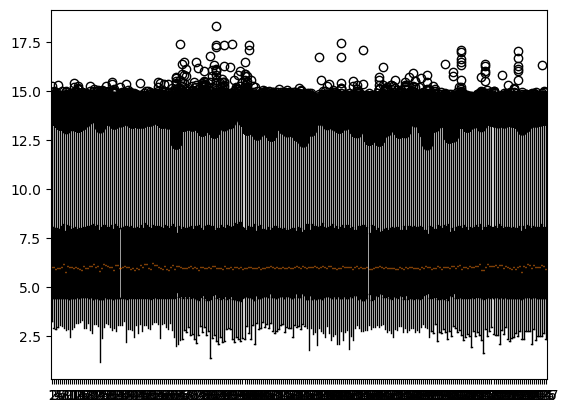

In [21]:
# normalize expression data
from inmoose.pycombat import pycombat_norm


# run pycombat_norm
df_corrected = pycombat_norm(expression_data, batch)

# visualize results
plt.boxplot(df_corrected)
plt.show()

In [22]:
#save scaled data
df_corrected.to_csv("./data/combined_expression_data_scaled.csv", index=True)

In [23]:
#load scaled data
df_corrected = pd.read_csv("./data/combined_expression_data_scaled.csv", index_col=0)

In [24]:
metadata.head()

,dataset,geo_accession,cancer_type,metastasis_status,time
GSM525806,GSE21050,GSM525806,Liposarcoma - dedifferentiated,False,9.00
GSM525811,GSE21050,GSM525811,Liposarcoma - dedifferentiated,True,0.95
GSM525812,GSE21050,GSM525812,Liposarcoma - dedifferentiated,True,0.87
GSM525814,GSE21050,GSM525814,Liposarcoma - dedifferentiated,False,2.84
GSM525818,GSE21050,GSM525818,Liposarcoma - dedifferentiated,False,4.04


# Univariate Cox analysis
The paper asserts that is uses Maximal Information Coefficient (MIC) to do feature selection. I  tried finding any information about this, but this seem very non-standard. I will instead be doing a univariate Cox survival analyis, and keep features with p<= 0.05. 

I will use the Lifeline package, because survkit in python does not support p-values.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter
import pandas as pd

In [26]:
metadata= pd.read_csv('data/combined_metadata.csv')
y= metadata[['geo_accession','metastasis_status','time']].set_index('geo_accession')
X = pd.read_csv('data/combined_expression_data_scaled.csv', index_col=0).convert_dtypes().transpose()

In [27]:
def fit_and_score_features2(X):
   y=X[["event_observed","duration"]]
   X.drop(["duration", "event_observed"], axis=1, inplace=True)
   n_features = X.shape[1]
   scores = np.empty(n_features)
   m = CoxPHFitter()

   for j in range(n_features):
       Xj = X.iloc[:, j:j+1]
       Xj=pd.merge(Xj, y,  how='right', left_index=True, right_index=True)
       m.fit(Xj, duration_col="duration", event_col="event_observed", show_progress=True)
       scores[j] = m.score_
   return scores

def fit_and_score_features(X, y):
    n_features = X.shape[1]
    scores = []
    # Fit a CoxPH model for each feature
    for j in range(n_features):
        Xj = X.iloc[:, j : j + 1] # Select one feature

        try:
            Xj = pd.merge(Xj, y, left_index=True, right_index=True)
            #Xj= Xj['1007_s_at'].drop_duplicates()
            m = CoxPHFitter()
            m.fit(Xj, 'time','metastasis_status' )
            scores.append(m.summary)
        except Exception as e:
            scores[j] = 0.0
    return scores

scores = fit_and_score_features(X, y)

In [28]:
df=pd.concat(scores, ignore_index=True)

In [29]:
df.index = X.columns
df.head()

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
ID_REF,,,,,,,,,,,
1007_s_at,0.052406,1.053804,0.169497,-0.279801,0.384614,0.755934,1.469047,0.0,0.309189,7.571780e-01,0.401296
1053_at,1.127196,3.086987,0.201514,0.732235,1.522156,2.079724,4.582094,0.0,5.593633,2.223668e-08,25.422483
117_at,0.120392,1.127939,0.092257,-0.060429,0.301213,0.941361,1.351498,0.0,1.304959,1.919067e-01,2.381523
121_at,-0.257783,0.772763,0.212171,-0.673630,0.158064,0.509854,1.171241,0.0,-1.214981,2.243733e-01,2.156027
1255_g_at,0.468415,1.597460,0.144028,0.186124,0.750706,1.204572,2.118494,0.0,3.252239,1.144996e-03,9.770441


In [30]:
df.to_csv('lifeline_univ_cox_pvals.csv')

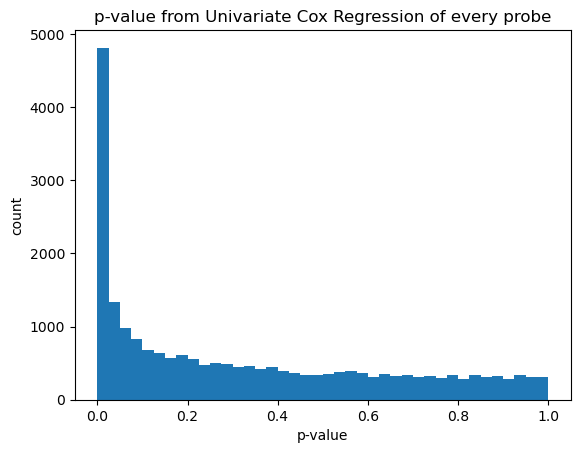

In [31]:
plot = plt.hist(df.p, bins=40)
plt.title('p-value from Univariate Cox Regression of every probe')
plt.xlabel('p-value')
plt.ylabel('count')
plt.show()

In [32]:
sig = df[df.p<=0.05].shape[0]

print(f"Perecent of probes that pass 0.05 cutoff: {sig / len(df):.2f}" )

Perecent of probes that pass 0.05 cutoff: 0.28


In [33]:
sig_ids = df[df.p<=0.05].index.to_list()
sig_expression = X.loc[:,sig_ids]
sig_expression.to_csv('./data/lifeline_univ_cox_sig_expression.csv')

In [34]:
print(f" Found {len(sig_ids)} probes with pval <= 0.05")

 Found 6150 probes with pval <= 0.05


# Testing multiple models

In [35]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sksurv.ensemble import RandomSurvivalForest
from sksurv.meta import EnsembleSelection
from sksurv.meta import EnsembleSelectionRegressor
from sksurv.svm import FastSurvivalSVM
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sksurv.metrics import (
    as_concordance_index_ipcw_scorer,
    as_cumulative_dynamic_auc_scorer,
    as_integrated_brier_score_scorer,
    concordance_index_ipcw
)

In [36]:
metadata= pd.read_csv('data/combined_metadata.csv')
y = Surv.from_arrays(event=metadata['metastasis_status'], time=metadata['time'])
X = pd.read_csv('data/lifeline_univ_cox_sig_expression.csv', index_col=0).convert_dtypes()

In [37]:
def remove_zero_time(y, X=None):
    """
    Remove samples with time == 0 from sksurv-formatted survival data.
    
    Parameters
    ----------
    y : structured array
        Survival array with fields ('event', 'time').
    X : array-like, optional
        Feature matrix corresponding to y.

    Returns
    -------
    y_filtered : structured array
    X_filtered : array-like (if X provided)
    """
    mask = y["time"] > 0
    y_filtered = y[mask]
    if X is not None:
        return y_filtered, X[mask]
    return y_filtered
y , X = remove_zero_time(y, X)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [39]:

def c_index_scorer(estimator, X, y):
    """
    Custom scorer for concordance index (C-index).
    
    Parameters:
    -----------
    estimator : sklearn estimator
        Fitted model
    X : array-like
        Features
    y : array-like
        Target values (risk scores or times)
    
    Returns:
    --------
    float : C-index score
    """
    #predictions = estimator.predict(X)
    #y_lifeline = convert_to_survival_format(y, return_df=True)

    return float(estimator.score(X,y))
    #concordance_index(y_lifeline['duration'], predictions, y_lifeline['event'])

for Enet papet mentions N1 hyperparam. I cant figure out what that it. the MIME paper uses alpha instead

Also they include testing data in the gridsearch, which seems wrong

In [40]:


# Define a generic pipeline with an 'estimator' placeholder
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('estimator', RandomSurvivalForest(random_state=42)) # Default estimator
])
#define base models
rsf = RandomSurvivalForest(random_state=42)
svm = FastSurvivalSVM(random_state=42)
lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
enet_a01 = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01)
enet_a05 = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.05)
enet_a1 = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.1)
enet_a5 = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.5)
boost_cox = GradientBoostingSurvivalAnalysis(learning_rate=1.0, max_depth=1, random_state=0)

#ensemble = EnsembleSelection([('rsf', rsf), ('svm',svm)], scorer=c_index_scorer)
ensemble = EnsembleSelection([('rsf', rsf), ('svm',svm)], scorer=c_index_scorer)




names_list = ['RSF',
    'SVM',
    'Lasso',
    'CoxBoost',
    r'Enet[$\alpha=0.01$]',
    r'Enet[$\alpha=0.05$]',
    r'Enet[$\alpha=0.1$]',
    r'Enet[$\alpha=0.5$]'
]
model_list = [rsf,
             svm,
             lasso,
             boost_cox,
             enet_a01,
             enet_a05,
             enet_a1,
             enet_a5
]

param_grid = [ {'estimator': [x]} for x in model_list]


# get all permutations of two models for ensamble method
import itertools
name_model =tuple(zip(names_list, model_list))
combos =[[a,b] for a, b in itertools.combinations(name_model,2)]


param_grid_ensamble = {
    'estimator': [ensemble],
    'estimator__base_estimators': combos
}

# Combine all parameter grids into a single list
full_param_grid = param_grid + [param_grid_ensamble]


In [41]:
# get the full list of models
# combos is two tuples (name a, model a), (name b, model b)
combo_names = [f"{x[0][0]} + {x[1][0]}" for x in combos]
full_name_list = names_list + combo_names

In [42]:
# Assuming appropriate X and y data (y should be a structured array)
# X, y = load_veterans_lung_cancer() 

# Initialize GridSearchCV
grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=full_param_grid,
            cv=3,
            scoring=c_index_scorer,
            n_jobs=8,
            verbose=0
        )

# Fit the grid search to your training data (X_train, y_train)
grid_search.fit(X_train, y_train) 


/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sklearn/pipeline.py:663: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  self._final_estimator.fit(Xt, y, **last_step_params["fit"])
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sklearn/pipeline.py:663: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  self._final_estimator.fit(Xt, y, **last_step_params["fit"])
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sklearn/pipeline.py:663: ConvergenceWarning: Optimization did not converge: Warning: Maximum number of iterations has been exceeded.
  self._final_estimator.fit(Xt, y, **last_step_params["fit"])
/projectnb/wax-es/alecs/.conda/envs/bf550-final-env/lib/python3.10/site-packages/sksurv/meta/base.py:25: ConvergenceWarning: Optimization did not converge: Warning: Maximum

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'estimator': [RandomSurviva...ndom_state=42)]}, {'estimator': [FastSurvivalS...ndom_state=42)]}, ...]"
,scoring,<function c_i...x14b0bda98e50>
,n_jobs,8
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [43]:
# The best_params_ and best_score_ attributes are not available when refit=False
# You need to manually find the best results from cv_results_
results = grid_search.cv_results_
# Find the index of the best score
best_index = np.argmax(results['mean_test_score'])
best_score = results['mean_test_score'][best_index]
best_params = results['params'][best_index]

print(f"Best score (C-index): {best_score}")
print(f"Best parameters: {best_params}")


Best score (C-index): 0.810482874643924
Best parameters: {'estimator': EnsembleSelection(base_estimators=[('rsf',
                                    RandomSurvivalForest(random_state=42)),
                                   ('svm', FastSurvivalSVM(random_state=42))],
                  scorer=<function c_index_scorer at 0x14b0bda98e50>), 'estimator__base_estimators': [('SVM', FastSurvivalSVM(random_state=42)), ('Lasso', CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=1.0))]}


In [44]:
# test best model on test data
best_model = grid_search.best_estimator_
best_model.fit(X_train,y_train)
test_score = best_model.score(X_test,y_test)
print(f"Best model:{best_model}, with c-index:{test_score:.2f}")

Best model:Pipeline(steps=[('scaler', StandardScaler()),
                ('estimator',
                 EnsembleSelection(base_estimators=[('SVM',
                                                     FastSurvivalSVM(random_state=42)),
                                                    ('Lasso',
                                                     CoxnetSurvivalAnalysis(alpha_min_ratio=0.01,
                                                                            l1_ratio=1.0))],
                                   scorer=<function c_index_scorer at 0x14b0bda98e50>))]), with c-index:0.80


In [45]:
# get the gene annotations from one of the files
#they are all the same
gene_info = gse21050.gpls['GPL570'].table

In [46]:
#finaly lets annotate with gene symbols
#gene_info = pd.read_csv('data/gene_feature_scores_annotation.csv', index_col=0)

In [47]:
results_df = pd.DataFrame(results)
results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator,param_estimator__base_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,2.897273,0.086681,0.289435,0.002162,RandomSurvivalForest(random_state=42),NaN,{'estimator': RandomSurvivalForest(random_stat...,0.755102,0.805901,0.767318,0.776107,0.021650,27
1,1.439004,0.062917,0.291186,0.004162,FastSurvivalSVM(random_state=42),NaN,{'estimator': FastSurvivalSVM(random_state=42)},0.806122,0.805901,0.818828,0.810284,0.006042,6
2,1.473878,0.098185,0.287095,0.004807,"CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l...",NaN,{'estimator': CoxnetSurvivalAnalysis(alpha_min...,0.734694,0.805901,0.808171,0.782922,0.034115,23
3,7.741308,0.041963,0.290335,0.006656,GradientBoostingSurvivalAnalysis(learning_rate...,NaN,{'estimator': GradientBoostingSurvivalAnalysis...,0.759354,0.697205,0.772647,0.743068,0.032881,36
4,1.392323,0.085521,0.287851,0.003889,"CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l...",NaN,{'estimator': CoxnetSurvivalAnalysis(alpha_min...,0.756803,0.813665,0.804618,0.791695,0.024948,8


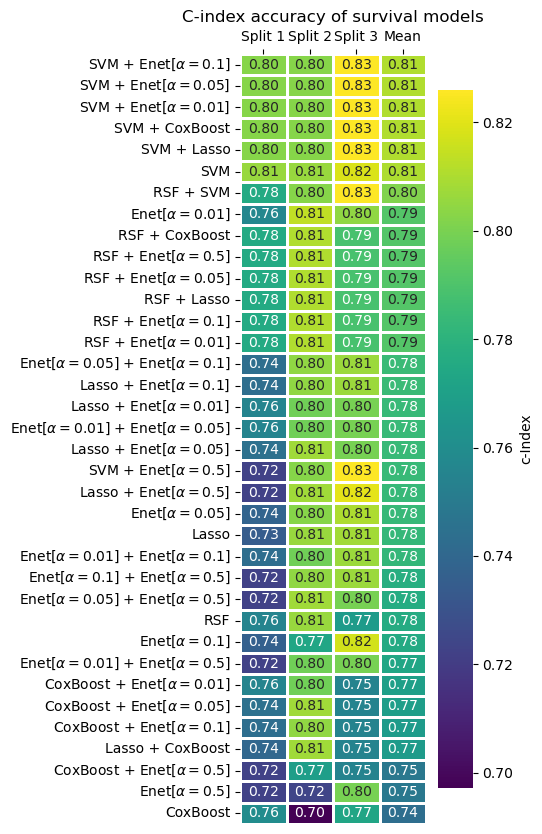

In [48]:
# add in nice names
results_df['model_name'] = full_name_list

df_sorted = results_df.sort_values("mean_test_score", ascending=False)

heat_data = df_sorted[['split0_test_score', 'split1_test_score', 'split2_test_score', "mean_test_score"]]
fig = plt.figure(figsize=(3, 10))
ax = sns.heatmap(
    heat_data,
    cmap="viridis",
    cbar=True,
    annot=True,         # ← add values inside cells
    fmt="0.2f",
    linewidths=1,
    yticklabels=df_sorted["model_name"],
    xticklabels=['Split 1', 'Split 2','Split 3', 'Mean'],
    cbar_kws={'label': 'c-Index'}
)
ax.xaxis.tick_top()
ax.set_title("C-index accuracy of survival models")
fig.savefig('Figures/model_selection.png', bbox_inches='tight')
plt.show()


# finding optimal alpha for E-net


In [49]:
import warnings
from sklearn.pipeline import make_pipeline
from sklearn.exceptions import FitFailedWarning

coxnet_pipe = make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=100))
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FitFailedWarning)
coxnet_pipe.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('coxnetsurvivalanalysis', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_alphas,100
,alphas,None
,alpha_min_ratio,0.01
,l1_ratio,0.9


In [50]:
#normaly we would test all the alpha values.
#to save time and computation, I will check every third
estimated_alphas = coxnet_pipe.named_steps["coxnetsurvivalanalysis"].alphas_
print("original sampling", estimated_alphas.shape)
mini_alphas = estimated_alphas[::3]
print("testing size", mini_alphas.size)

original sampling (100,)
testing size 34


In [51]:
#test different alpha values to determine best
cv = KFold(n_splits=3, shuffle=True, random_state=0)
gcv = GridSearchCV(
    make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9)),
    param_grid={"coxnetsurvivalanalysis__alphas": [[v] for v in map(float, mini_alphas)]},
    cv=cv,
    error_score=0.5,
    n_jobs=8,
).fit(X_train, y_train)

cv_results = pd.DataFrame(gcv.cv_results_)

In [52]:
cv_results.to_csv('data/determening_alpha_for_Enet.csv')

In [53]:
import pickle

with open("data/gridsearch.pkl", "wb") as f:
    pickle.dump(gcv, f)

In [54]:
cv_results = pd.read_csv('data/determening_alpha_for_Enet.csv', index_col=0)

In [55]:
#the alphas are saved as '[000.000]' so strip [] and convert to number
cv_results.param_coxnetsurvivalanalysis__alphas = cv_results.param_coxnetsurvivalanalysis__alphas.str.strip('[]').astype('float')

best alpha 0.0648024209138061


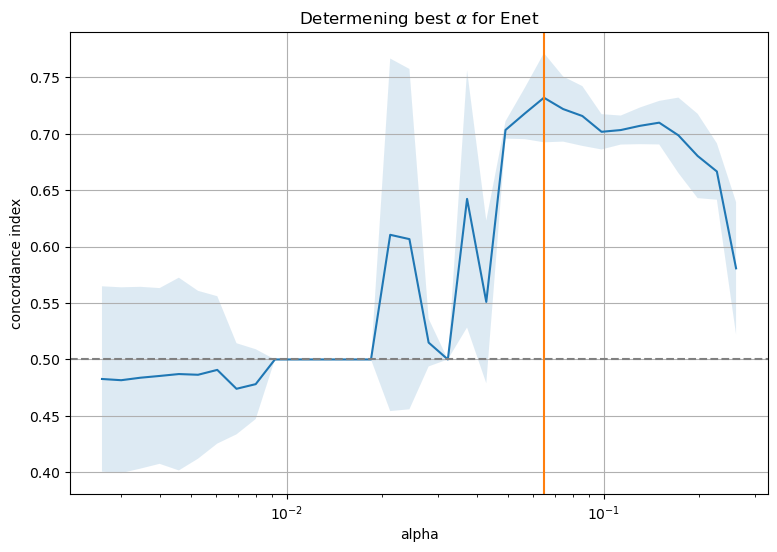

In [56]:
#plot alpha results
alphas = cv_results.param_coxnetsurvivalanalysis__alphas #.map(lambda x: x[0])
mean = cv_results.mean_test_score
std = cv_results.std_test_score

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(alphas, mean)
ax.fill_between(alphas, mean - std, mean + std, alpha=0.15)
ax.set_xscale("log")
ax.set_ylabel("concordance index")
ax.set_xlabel("alpha")
ax.axvline(gcv.best_params_["coxnetsurvivalanalysis__alphas"][0], c="C1")
ax.axhline(0.5, color="grey", linestyle="--")
ax.grid(True)
best_alpha=gcv.best_params_["coxnetsurvivalanalysis__alphas"][0]
ax.set_title(f"Determening best $\\alpha$ for Enet ")
print("best alpha", best_alpha)

Number of non-zero coefficients: 59


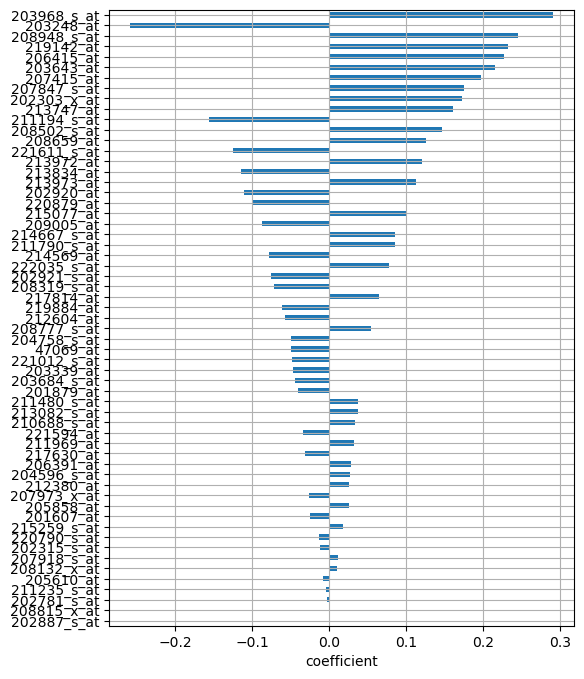

In [57]:
#try Enet 1 time to evaluate results
best_model = gcv.best_estimator_.named_steps["coxnetsurvivalanalysis"]
best_coefs = pd.DataFrame(best_model.coef_, index=X.columns, columns=["coefficient"])

non_zero = np.sum(best_coefs.iloc[:, 0] != 0)
print(f"Number of non-zero coefficients: {non_zero}")

non_zero_coefs = best_coefs.query("coefficient != 0")
coef_order = non_zero_coefs.abs().sort_values("coefficient").index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax=ax, legend=False)
ax.set_xlabel("coefficient")
ax.grid(True)

In Mime defualts, they use LASSO 1000 times and keep anything that apears 50 times or more.
I will run Enet 100 times and keep anything 10 or more

In [58]:
from collections import Counter
#refit to shuffled data and count how many times things show up
total = Counter()
for i in range(100):
    #X_mix , y_mix = shuffle(X_train, y_train, random_state=i)
    X_mix, X_ignore, y_mix, y_ignore = train_test_split(X_train, y_train, test_size=0.1, random_state=i)
    best_model.fit(X_mix,y_mix)
    best_coefs = pd.DataFrame(best_model.coef_, index=X.columns, columns=["coefficient"])

    non_zero = np.sum(best_coefs.iloc[:, 0] != 0)

    non_zero_coefs = best_coefs.query("coefficient != 0")
    counts = Counter(non_zero_coefs.index.to_list())
    total = total + counts


In [79]:
series_total = pd.Series(total)

In [80]:
#finaly lets annotate with gene symbols
#gene_info = pd.read_csv('data/gene_feature_scores_annotation.csv', index_col=0)


In [81]:
#filter for things with over 20 counts
series_total = series_total[series_total>=20]


In [82]:
# and combine with gene annotations by probe id
series_total.name = 'enet_counts'
enet_counts = pd.merge(series_total, gene_info, how='inner', left_index=True, right_on='ID')
enet_counts = enet_counts.groupby('Gene Symbol')['enet_counts'].mean()

#sort by result
enet_counts = enet_counts.sort_values(ascending=False)
enet_counts[0:30]

Gene Symbol
LPPR4                     98.0
SERPINB2                  98.0
ECM2                      96.0
CPA3                      96.0
AVIL                      96.0
LEF1                      94.0
COPG2IT1                  94.0
GPR64                     94.0
LOC100506558 /// MATN2    93.0
HAS1                      91.0
PNMA2                     91.0
IGF2BP3                   88.0
INHBA                     88.0
MFAP5                     85.0
LGR5                      83.0
SULF1                     82.0
G0S2                      82.0
PTER                      79.0
SF1                       78.0
PLCB4                     76.0
RASL11B                   76.0
MDM2                      71.5
TERT                      70.0
ITM2A                     67.0
CPE                       65.0
FMO1                      65.0
ANK2                      62.5
MMP1                      61.0
PROM1                     59.0
ADH1C                     56.0
Name: enet_counts, dtype: float64

# Feature Importance With Selected Features

In [83]:
# reduce our training data to only selected features
features_keep =list(series_total.index)
X_train_sel = X_train[features_keep]
X_test_sel = X_test[features_keep]


In [84]:
print(f"Fitting SVM")
#refit with original features
best_model = svm #grid_search.best_estimator_
best_model.fit(X_train, y_train)
og_test_score = best_model.score(X_test, y_test)

#now with selected features
best_model.fit(X_train_sel, y_train)

# Evaluate model performance (C-index)
train_score = best_model.score(X_train_sel, y_train)
test_score = best_model.score(X_test_sel, y_test)
print(f"\nModel Performance (C-index):")
print(f"Training score: {train_score:.4f}")
print(f"Testing score before additional feature selection: {og_test_score:.4f}")
print(f"Testing score: {test_score:.4f}")

#some additional stats
print(f"\nNumber of probes before: {X.shape[1]}")
print(f"Number of probes now: {X_train_sel.shape[1]}")

#extract feature importances using permutation importance
from sklearn.inspection import permutation_importance
result = permutation_importance(best_model, 
                                X_test_sel, 
                                y_test, n_repeats=20, random_state=42, n_jobs=8)


Fitting SVM



Model Performance (C-index):
Training score: 1.0000
Testing score before additional feature selection: 0.7970
Testing score: 0.7970

Number of probes before: 6150
Number of probes now: 82


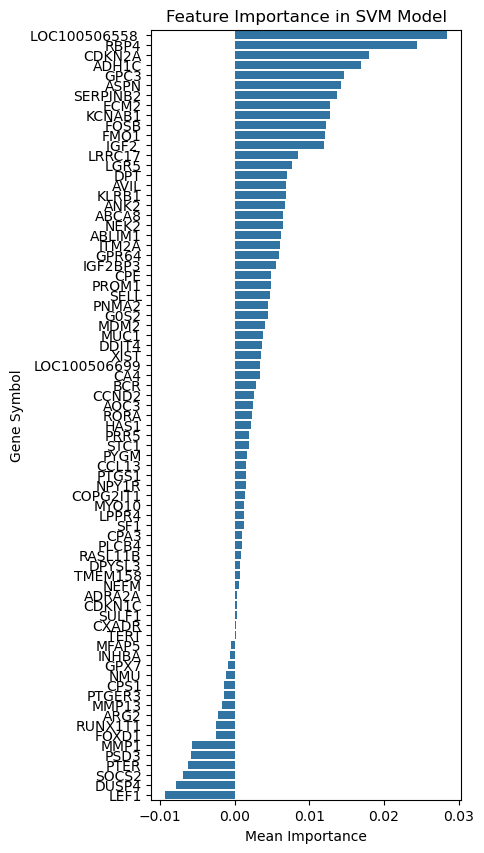

In [85]:
result_df = pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=X_test_sel.columns,
)
merge = pd.merge(result_df, gene_info, how='inner', left_index=True, right_on='ID')
merge = merge.groupby('Gene Symbol')[['importances_mean', 'importances_std']].mean()

df_sorted = merge.sort_values('importances_mean', ascending=False)



#and remove extra genes from indeces 
#some have 10+ and messes up chart
df_sorted.index = df_sorted.index.str.split("///", n=1).str[0]


fig = plt.figure(figsize=(4, 10))
sns.barplot(
    data=df_sorted,
    x='importances_mean',
    y="Gene Symbol",
)

plt.xlabel("Mean Importance")
plt.ylabel("Gene Symbol")
plt.title("Feature Importance in SVM Model")
#plt.tight_layout()
fig.savefig('Figures/feature_importance.png', bbox_inches='tight')
plt.show()

# Testing predictions of final model

Note from Scikit surviaval site 

> For other survival models that do not rely on the proportional hazards assumption, it is often impossible to estimate survival or cumulative hazard function. Their predictions are risk scores of arbitrary scale. If samples are ordered according to their predicted risk score (in ascending order), one obtains the sequence of events, as predicted by the model. This is the return value of the predict() method of all survival models in scikit-survival.


In [86]:
# get the predicted scores for test data
prediction_score = best_model.predict(X_test_sel)

#bin into bottom mid and top scores
quants = np.quantile(prediction_score, [0.25,0.75])
bins = np.searchsorted(quants, prediction_score)


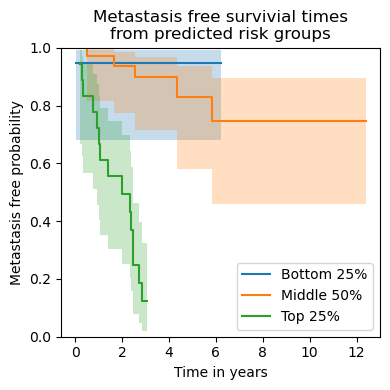

In [87]:
# make a simple survival analysis dataframe
iter_vals = [0,1,2]
iter_names = ['Bottom 25%', 'Middle 50%', 'Top 25%']

fig = plt.figure(figsize=(4, 4))
for i, name in zip(iter_vals,iter_names):
    predictions = y_test[bins == i]
    time, survival_prob, conf_int = kaplan_meier_estimator(
        predictions['event'], predictions['time'], conf_type="log-log"
    )

    plt.step(time, survival_prob, where="post", label=name )
    plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
    
plt.ylim(0, 1)
plt.ylabel(r"Metastasis free probability")
plt.xlabel("Time in years")
plt.title("Metastasis free survivial times\nfrom predicted risk groups")
plt.legend()
plt.tight_layout()
fig.savefig('Figures/survival_curves.png')
plt.show()

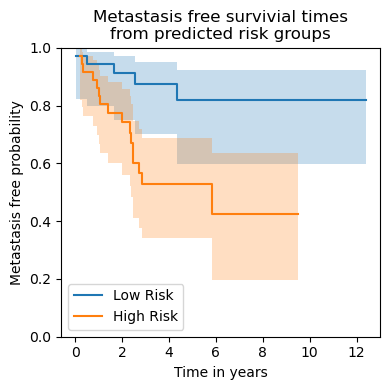

In [88]:
# get the predicted scores for test data
prediction_score = best_model.predict(X_test_sel)

#bin into bottom mid and top scores
quants = np.quantile(prediction_score, [0.5])
bins = np.searchsorted(quants, prediction_score)

# make a simple survival analysis dataframe
iter_vals = [0,1]
iter_names = ['Low Risk', 'High Risk']

fig = plt.figure(figsize=(4, 4))
for i, name in zip(iter_vals,iter_names):
    predictions = y_test[bins == i]
    time, survival_prob, conf_int = kaplan_meier_estimator(
        predictions['event'], predictions['time'], conf_type="log-log"
    )

    plt.step(time, survival_prob, where="post", label=name )
    plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
    
plt.ylim(0, 1)
plt.ylabel(r"Metastasis free probability")
plt.xlabel("Time in years")
plt.title("Metastasis free survivial times\nfrom predicted risk groups")
plt.legend()
plt.tight_layout()
fig.savefig('Figures/survival_curves_high_low.png')
plt.show()